I0000 00:00:1773868944.868244   23079 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773868944.869569   23079 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773868944.954902   23079 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773868947.501250   23079 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Epoch 1/120
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 135ms/step - loss: 7.2623e-04 - mae: 0.0250 - val_loss: 3.3223e-04 - val_mae: 0.0180 - learning_rate: 0.0010
Epoch 2/120
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - loss: 7.1954e-04 - mae: 0.0247 - val_loss: 3.3249e-04 - val_mae: 0.0180 - learning_rate: 0.0010
Epoch 3/120
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 132ms/step - loss: 7.1957e-04 - mae: 0.0247 - val_loss: 3.3259e-04 - val_mae: 0.0180 - learning_rate: 0.0010
Epoch 4/120
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 133ms/step - loss: 7.1959e-04 - mae: 0.0247 - val_loss: 3.3263e-04 - val_mae: 0.0180 - learning_rate: 0.0010
Epoch 5/120
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 129ms/step - loss: 7.1961e-04 - mae: 0.0247 - val_loss: 3.3266e-04 - val_mae: 0.0180 - learning_rate: 0.0010
Epoch 6/120
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - loss: 7.1962e-04 - mae: 0.0247 - val_loss: 3.3268e-04 - val_mae: 0.0180 - learning_rate: 0.0010
Epoch 7/120
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 129ms/step - loss: 7.1795e-04 - mae: 0.0247 -

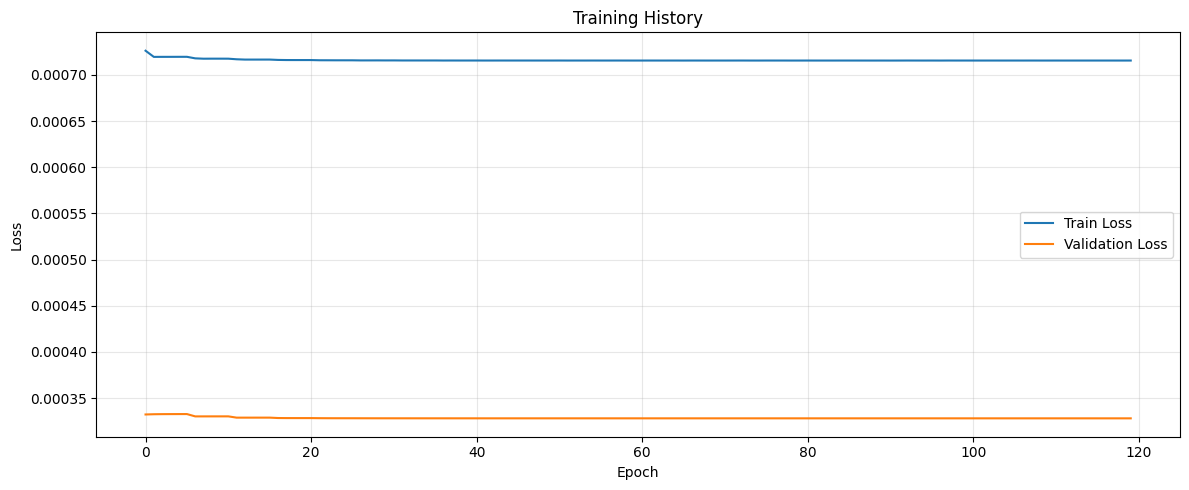

In [1]:
from model_class import BitcoinLSTMModel, BitcoinLSTMPlotter, ModelConfig

config = ModelConfig(
    ticker="BTC-USD",
    lookback=120,
    horizon_days=366,
    epochs=120,
    batch_size=32
)

model = BitcoinLSTMModel(config)

df = model.download_data("2014-01-01", "2025-12-31")
model.set_history_data(df)

model.build_model()
history = model.train(
    train_end_date="2024-12-31",
    save_best_path="./best_model.keras"
)

model.save("./btc_saved_model")

BitcoinLSTMPlotter.plot_training_history(history)

            Predicted_Log_Return  Predicted_Close  Actual_Close
2025-01-01              0.001420     93561.953125  94419.757812
2025-01-02              0.001399     93692.937500  96886.875000
2025-01-03              0.001462     93830.023438  98107.429688
2025-01-04              0.001549     93975.468750  98236.226562
2025-01-05              0.001445     94111.343750  98314.960938
            Predicted_Log_Return  Predicted_Close  Actual_Close
2025-12-27              0.001556    166459.343750  87802.156250
2025-12-28              0.001622    166729.578125  87835.835938
2025-12-29              0.001633    167002.046875  87138.140625
2025-12-30              0.001695    167285.406250  88430.132812
2025-12-31              0.001690    167568.296875  87508.828125


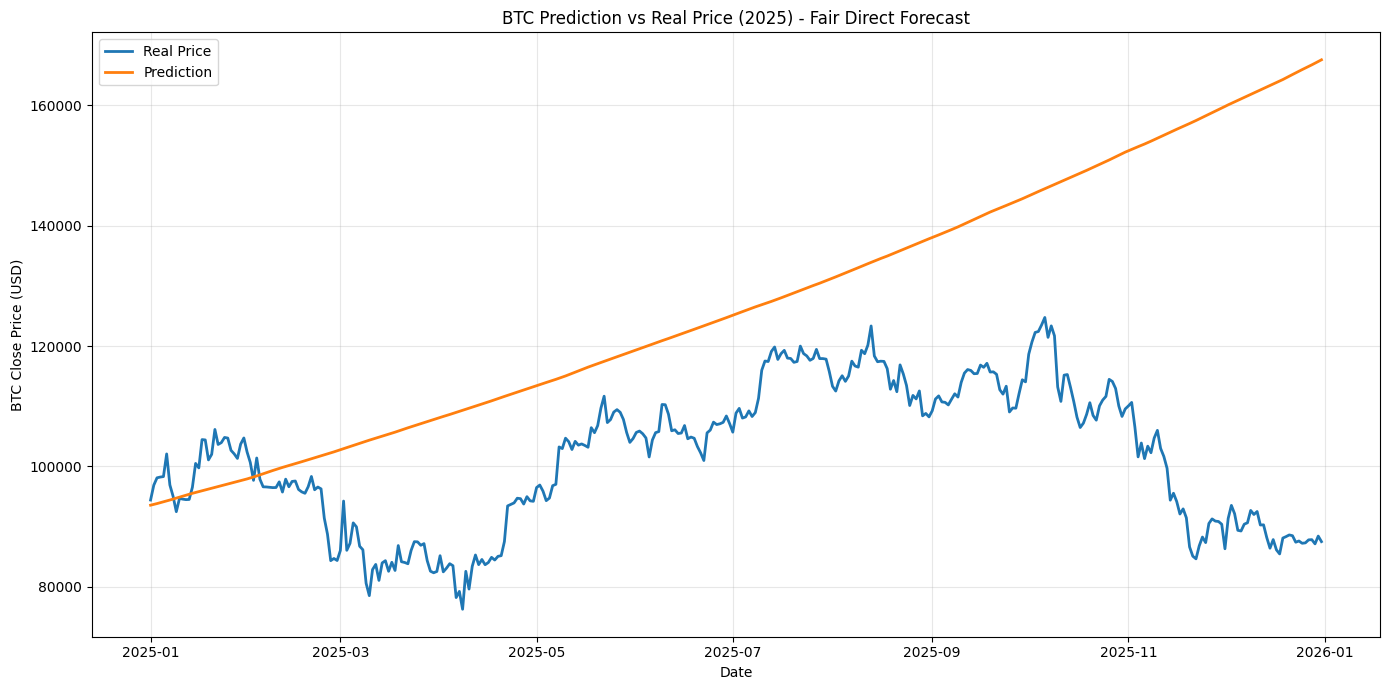

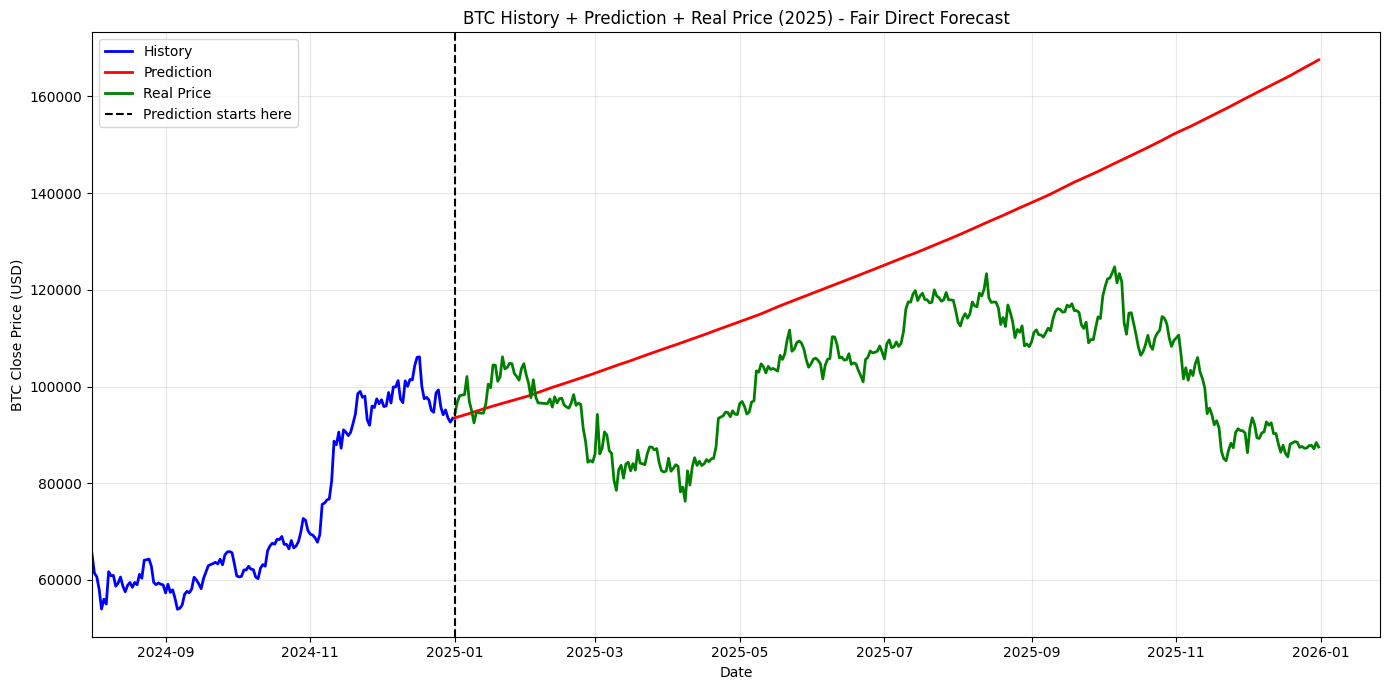

In [2]:
from model_class import BitcoinLSTMModel, BitcoinLSTMPlotter

model = BitcoinLSTMModel.load("./btc_saved_model")

df = model.download_data("2014-01-01", "2025-12-31")
model.set_history_data(df)

pred_2025 = model.predict_range(
    forecast_start_date="2025-01-01",
    forecast_end_date="2025-12-31"
)

print(pred_2025.head())
print(pred_2025.tail())

BitcoinLSTMPlotter.plot_prediction_vs_actual(
    pred_df=pred_2025,
    title="BTC Prediction vs Real Price (2025) - Fair Direct Forecast"
)

BitcoinLSTMPlotter.plot_history_prediction(
    history_df=model.history_df,
    pred_df=pred_2025,
    plot_from_date="2024-08-01",
    forecast_start_date="2025-01-01",
    title="BTC History + Prediction + Real Price (2025) - Fair Direct Forecast"
)

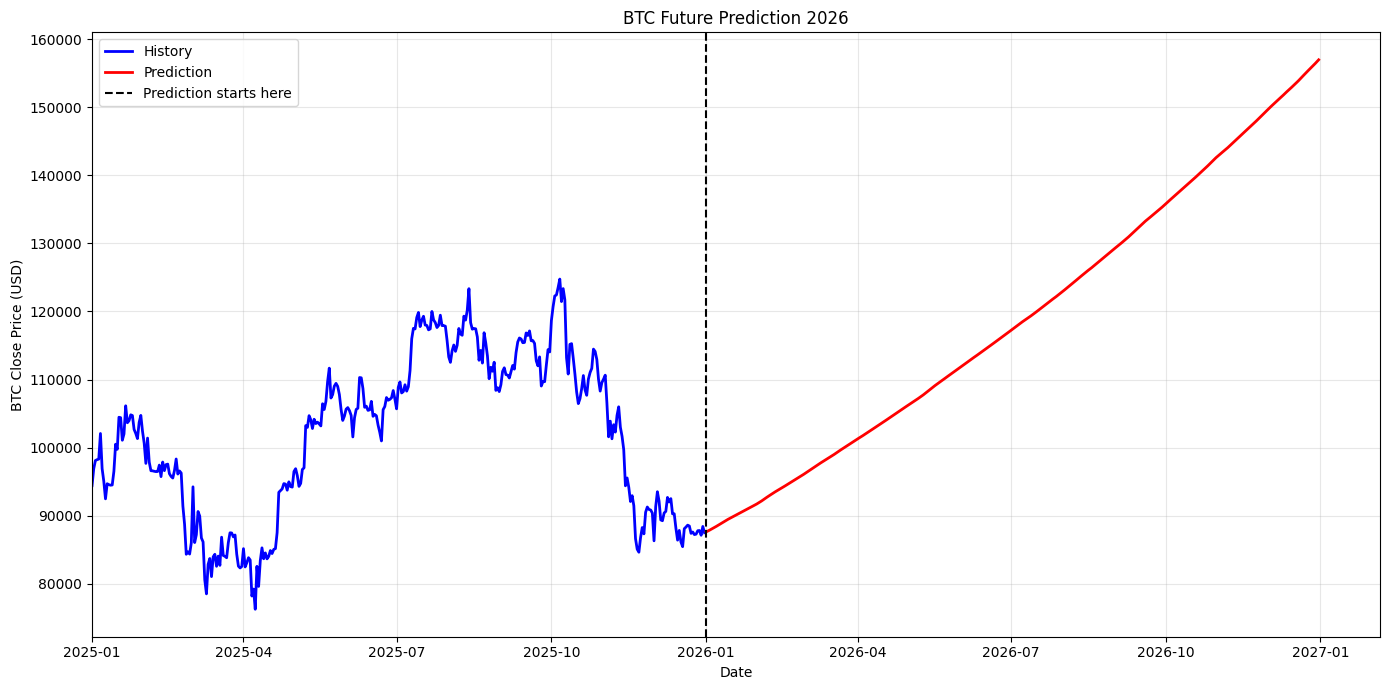

In [3]:
from model_class import BitcoinLSTMModel, BitcoinLSTMPlotter

model = BitcoinLSTMModel.load("./btc_saved_model")

df = model.download_data("2014-01-01", "2025-12-31")
model.set_history_data(df)

pred_2026 = model.predict_range(
    forecast_start_date="2026-01-01",
    forecast_end_date="2026-12-31"
)

BitcoinLSTMPlotter.plot_history_prediction(
    history_df=model.history_df,
    pred_df=pred_2026,
    plot_from_date="2025-01-01",
    forecast_start_date="2026-01-01",
    title="BTC Future Prediction 2026"
)